## Exercise 3 - simple 3D differentiable rendering

This exercise extends the previous in two ways:
1. We've moved from 2D to 3D, dealing with spheres instead of circles.
2. Instead of a single object, you'll recover the parameters of 5 different spheres.

When viewed from a specific angle (provided by a helper function), the spheres encode a 5-digit binary number. **Who'll be the first to crack the code?**

### Imports

In [1]:
import torch
from utils.ex3 import *

### Loading and visualizing the ground truth renders

This time we have 3 renders, one for each projection on the `X-Y`, `X-Z` and `Y-Z` planes.

Importantly, each render contains information about the identity of the spheres, so that they can be correlated across renders. To account for this, we'll split each ground truth render to 5 "layers", one for each sphere.

Notice:
1. The renders' extents
2. The shape of how we represent each render

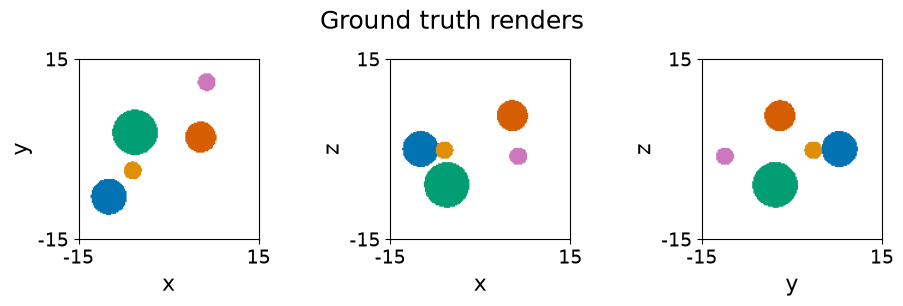

GT shapes: torch.Size([5, 150, 150]) torch.Size([5, 150, 150]) torch.Size([5, 150, 150])


In [2]:
xy, xz, yz = [torch.tensor(gt_rendering) for gt_rendering in load_gt()]
print('GT shapes:', xy.shape, xz.shape, yz.shape)

### Rendering function
Implement the rendering function. It should accept all the spheres' parameters and the projection axes, and return a tensor of the same shape as the ground truth renders representing the rendering result.

#### Sphere representation

Each sphere is represented by 4 parameters: $ (radius, c_x, c_y, c_z) $.

As the scene contains 5 spheres, you'll represent it as a 5-by-4 tensor (shape `(5, 4)`) where the entry at index `0` contains the firs sphere's parameters, entry at index `1` contains the second sphere's parameters, and so on.

#### Axes projection
How do we project a 3D sphere onto certain axes? We simply discard the axis that was left out and proceed as if ther sphere were a 2D circle. For example, to project a sphere to the `X-Z` plane, we discard $ c_y $ and perform a 2D rendering with center $ (c_x, c_z) $ and $ radius $.

In [3]:
def render(params, axes):
    x = torch.linspace(-15, 15, 150)
    y = torch.linspace(-15, 15, 150)
    xx, yy = torch.meshgrid(x, y, indexing='xy')
    z = []
    for p in params:
        r = p[0]
        px = p[1:][axes[0]] * 15
        py = p[1:][axes[1]] * 15
        d = torch.sqrt((xx - px) ** 2 + (yy - py) ** 2)
        z.append(1 / (1 + torch.exp(-1 * (r - d))))

    return torch.stack(z, dim=0)

### Initialization and optimization

Initialize the parameters and optimizer, and implement gradient descent. You'll need to tune hyper-parameters and play with relative parameter scales.

Use the following helper functions to get a visualization of the optimization:
1. `reset_history()` before the optimization
2. `log_history(renders, loss, params)` in every iteration.
* `renders` should be a tuple of 3 rendering results from projections `X-Y`, `X-Z`, `Y-Z`; each render should have 5 layers (same shape as the ground truth)
* `loss` the scalar value you're minimizing
* A 5-by-4 tensor representing the spheres' parameters. Make sure to pass the "final" parameters, e.g. after scaling has been taken into account
3. `visualize_history()` after the optimization

optimizing: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:01<00:00, 130.85it/s, loss=0.00615]


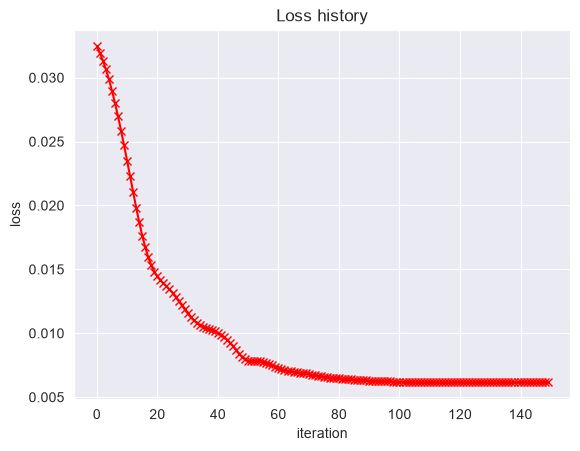

Rendering optimization: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:07<00:00, 21.27it/s]


In [4]:
def calc_loss(params):
    render_xy = render(params, (0, 1))
    render_xz = render(params, (0, 2))
    render_yz = render(params, (1, 2))
    return sum([
        ((render_xy - xy) ** 2).mean(),
        ((render_xz - xz) ** 2).mean(),
        ((render_yz - yz) ** 2).mean(),
    ]) / 3, (render_xy, render_xz, render_yz)


params = torch.tensor([
    [2., 0, 0, 0]
    for i in range(5)
], requires_grad=True)

optimizer = torch.optim.Adam([params], lr=1e-2 * 2)

pbar = tqdm(range(150), desc='optimizing')
reset_history()
for iter in pbar:
    loss, renders = calc_loss(params)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    curr = params.clone()
    curr[:, 1:] *= 15

    pbar.set_postfix({'loss': float(loss.detach())})
    log_history(renders, loss, curr)

visualize_history()